# Day 17 — RNN

## Mini Project: IMDB Sentiment Analysis

Training is set to **1 epoch**.

## 1. Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 2. Load IMDB Dataset

`0 = Negative`, `1 = Positive`

In [ ]:
VOCAB_SIZE = 10000
MAX_LENGTH = 200
(train_x, train_y), (test_x, test_y) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
print('Training samples:', len(train_x))
print('Testing samples:', len(test_x))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples: 25000


## 3. Pad Sequences

In [ ]:
train_x = keras.utils.pad_sequences(train_x, maxlen=MAX_LENGTH, padding='post', truncating='post')
test_x = keras.utils.pad_sequences(test_x, maxlen=MAX_LENGTH, padding='post', truncating='post')
print('Training shape:', train_x.shape)
print('Testing shape:', test_x.shape)


Training shape: (25000, 200)
Testing shape: (25000, 200)


## 4. Build RNN Model

`Embedding → SimpleRNN → Dense`

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


## 6. Train — 1 Epoch

In [ ]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=1, batch_size=64)


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.5038 - loss: 0.6941 - val_accuracy: 0.4938 - val_loss: 0.7014


## 7. Accuracy

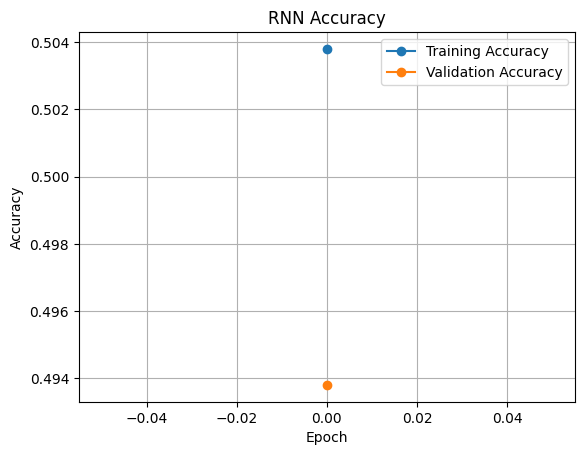

In [ ]:
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('RNN Accuracy'); plt.legend(); plt.grid(); plt.show()


## 8. Loss

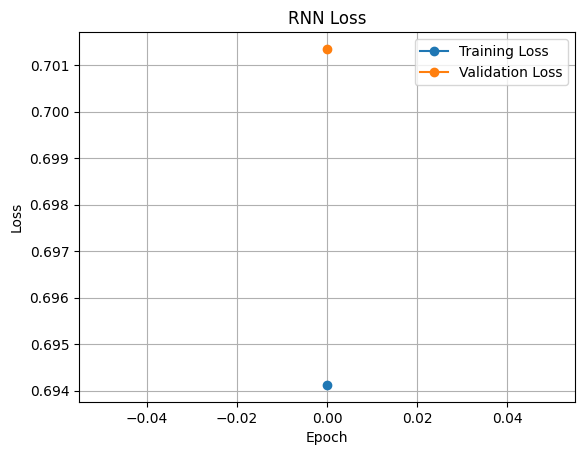

In [ ]:
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('RNN Loss'); plt.legend(); plt.grid(); plt.show()


## 9. Evaluate

In [ ]:
loss, accuracy = model.evaluate(test_x, test_y, verbose=0)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)


Test Loss: 0.7003644704818726
Test Accuracy: 0.5017200112342834


## 10. Predictions

In [ ]:
probabilities = model.predict(test_x[:10], verbose=0).flatten()
predictions = (probabilities >= 0.5).astype(int)
print('Predicted:', predictions)
print('Actual   :', test_y[:10])


Predicted: [1 1 1 1 1 1 1 1 1 1]
Actual   : [0 1 1 0 1 1 1 0 0 1]


# Day 17 Revision

**RNN:** neural network for sequential data.

**Hidden State:** carries information from previous time steps.

**Embedding:** converts token IDs into dense vectors.

**Padding:** makes sequences equal length.

## Notebook Summary: IMDB Sentiment Analysis with RNN

This notebook demonstrates a complete workflow for building a Recurrent Neural Network (RNN) to perform sentiment analysis on the IMDB movie review dataset.

1.  **Data Preparation**: We loaded the IMDB dataset, restricting it to the top 10,000 most frequent words. Sequences were then padded/truncated to a fixed length of 200 to ensure uniform input shapes for the model.
2.  **Model Architecture**: A Sequential model was constructed using:
    *   **Embedding Layer**: Maps word indices to 32-dimensional dense vectors.
    *   **SimpleRNN Layer**: Processes the sequence, maintaining a hidden state to capture temporal dependencies.
    *   **Dense Layer**: A single neuron with a Sigmoid activation function to output a probability (0 for negative, 1 for positive).
3.  **Training**: The model was compiled with the Adam optimizer and trained for 1 epoch. Despite the brief training, the notebook sets up the necessary infrastructure for monitoring accuracy and loss.
4.  **Evaluation**: We evaluated the model on unseen test data and generated predictions, comparing the predicted labels against the actual sentiments of movie reviews.